# EDA CSV DINOSAURI

In [1]:
# Importare le librerie
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
import category_encoders as ce
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import RobustScaler

In [2]:
# Leggere il file CSV 'dinos.csv' e caricarlo in un DataFrame 
df = pd.read_csv('dinos.csv')
print(df)

       occurrence_no record_type  reid_no flags  collection_no  \
0              41524         occ      NaN   NaN           3257   
1              41580         occ      NaN   NaN           3256   
2             130209         occ      NaN   NaN          10755   
3             130294         occ      NaN   NaN          10764   
4             130295         occ      NaN   NaN          10764   
...              ...         ...      ...   ...            ...   
37785        2065727         occ      NaN   NaN         193775   
37786        2066133         occ      NaN   NaN         279153   
37787        2066134         occ      NaN   NaN         279153   
37788        2066135         occ      NaN   NaN         279154   
37789        2066136         occ      NaN   NaN         279154   

                                  identified_name identified_rank  \
0                                     Aves indet.           class   
1                                     Aves indet.           class   


In [3]:
# Prime cinque righe
df.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,at Dummer's Copse between Allington Lane and Q...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,"at Dummer's Copse, between Allington Lane and ...",37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,"Chaoyang area of Liaoning Province, NE China",2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx


In [4]:
# Informazioni generali
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37790 entries, 0 to 37789
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     37790 non-null  int64  
 1   record_type       37790 non-null  str    
 2   reid_no           4154 non-null   float64
 3   flags             3417 non-null   str    
 4   collection_no     37790 non-null  int64  
 5   identified_name   37790 non-null  str    
 6   identified_rank   37790 non-null  str    
 7   identified_no     12703 non-null  float64
 8   difference        3889 non-null   str    
 9   accepted_name     37790 non-null  str    
 10  accepted_attr     37748 non-null  str    
 11  accepted_rank     37790 non-null  str    
 12  accepted_no       37790 non-null  int64  
 13  early_interval    37790 non-null  str    
 14  late_interval     8675 non-null   str    
 15  max_ma            37790 non-null  float64
 16  min_ma            37790 non-null  float64
 17  refe

## VALORI MANCANTI

In [5]:
# Valori NaN per colonna
df.isnull().sum()

occurrence_no           0
record_type             0
reid_no             33636
flags               34373
collection_no           0
identified_name         0
identified_rank         0
identified_no       25087
difference          33901
accepted_name           0
accepted_attr          42
accepted_rank           0
accepted_no             0
early_interval          0
late_interval       29115
max_ma                  0
min_ma                  0
reference_no            0
lng                     0
lat                     0
cc                     17
state                6320
county              19061
latlng_basis         1611
latlng_precision        0
altitude_value      29120
altitude_unit       29211
geogscale            6627
geogcomments         7883
cx_int_no              62
formation           14347
geological_group    27438
member              30582
phylum                  0
class                   0
order                7379
family               8723
genus               14232
dtype: int64

In [6]:
# Percentuale di valori nulli per ogni colonna
(df.isnull().sum() / len(df) * 100).round(2)

occurrence_no        0.00
record_type          0.00
reid_no             89.01
flags               90.96
collection_no        0.00
identified_name      0.00
identified_rank      0.00
identified_no       66.39
difference          89.71
accepted_name        0.00
accepted_attr        0.11
accepted_rank        0.00
accepted_no          0.00
early_interval       0.00
late_interval       77.04
max_ma               0.00
min_ma               0.00
reference_no         0.00
lng                  0.00
lat                  0.00
cc                   0.04
state               16.72
county              50.44
latlng_basis         4.26
latlng_precision     0.00
altitude_value      77.06
altitude_unit       77.30
geogscale           17.54
geogcomments        20.86
cx_int_no            0.16
formation           37.97
geological_group    72.61
member              80.93
phylum               0.00
class                0.00
order               19.53
family              23.08
genus               37.66
dtype: float

In [7]:
# Colonna cc --> codice paese
# Paesi più frequenti del dataset
print("--- Primi 10 Paesi per numero di ritrovamenti ---")
print(df['cc'].value_counts().head(10))

# Isolare le 17 righe dove 'cc' è nullo
print("\n--- Righe con valore 'cc' mancante ---")
print(df[df['cc'].isnull()][['accepted_name', 'lng', 'lat', 'cc']])

--- Primi 10 Paesi per numero di ritrovamenti ---
cc
US    11377
CA     2225
ES     2224
CN     1975
NZ     1268
AR     1215
UK     1184
FR     1037
MN      980
AU      830
Name: count, dtype: int64

--- Righe con valore 'cc' mancante ---
                     accepted_name        lng        lat   cc
141                   Accipitridae  16.500000 -28.250000  NaN
142                  Struthionidae  16.500000 -28.250000  NaN
143                    Phasianidae  16.500000 -28.250000  NaN
9902                          Aves  16.809999 -28.330000  NaN
14147   Namaortyx sperrgebietensis  15.416667 -27.266666  NaN
16300                    Theropoda  16.653521 -21.420189  NaN
16307                 Prosauropoda  16.653521 -21.420189  NaN
18389  Scopelortyx klinghardtensis  15.622301 -27.385286  NaN
18390      Namapsitta praeruptorum  15.622301 -27.385286  NaN
19135        Kayentapus damarensis  16.653521 -21.420189  NaN
19136                    Grallator  16.653521 -21.420189  NaN
28602        Kaye

In questo si potrebbe o sostitutire cc con "Sconosciuto" oppure ingorarlo essendoci ben definiti i valori di latituidine e longitutdine

In [8]:
# Colonna state --> ~17% mancanti
# Da quali paesi (cc) provengono principalmente i record con 'state' mancante?
print("\n--- Top 15 paesi (cc) tra le righe con 'state' nullo ---")
print(df[df['state'].isnull()]['cc'].value_counts().head(20))



--- Top 15 paesi (cc) tra le righe con 'state' nullo ---
cc
NZ    561
IT    351
ES    282
PF    251
UK    195
MP    191
SB    178
PN    175
RU    170
ZA    160
MG    155
NC    143
TO    142
PT    136
AQ    128
PE    128
GL    126
SH    120
CK    117
MU    115
Name: count, dtype: int64


Risultato probabilmente sistematico, può essere un limite per certi territori che non hanno una suddivisione dettagliata come invece il caso degli USA.
Anche qui si potrebbe inserire "Sconosciuto"

In [9]:
# Colonna formation (formazione geologica) --> ~38% mancanti
# In quali paesi si concentrano i valori NaN
df[df['formation'].isnull()]['cc'].value_counts().head(10)

cc
US    3530
NZ     999
ES     929
FR     639
IT     528
UK     423
GR     388
AU     315
CA     290
PF     280
Name: count, dtype: int64

In [10]:
# Controllo incrociato con colonne collegate
df[df['formation'].isnull()][['geological_group', 'member']].isnull().sum()

geological_group    13471
member              14281
dtype: int64

Probabilmente anche qui si tratta di un errore strutturale di documentazione, non casuale, quindi si potrebbe sostituire i NaN con "Non specificato" invece di eliminare le righe, per non perdere il 38% del dataset. 

In [11]:
# Colonna geological_group (Gruppo geologico)--> 72%
# Controllo incrociato con formation
df[df['geological_group'].isnull()][['formation']].isnull().sum()

formation    13471
dtype: int64

Qui anche senza sapere il gruppo geologico, nella maggior parte dei casi si conosce comunque la formazione specifica. geological_group è un'informazione aggiuntiva/opzionale, non un prerequisito per avere formation.

E sembra che anche in questo caso il dato manchi per limiti di documentazione, non casualmente. A differenza di formation/member però, sapere formation non implica sapere geological_group (e viceversa): sono parzialmente indipendenti. Si può sostituire con "Non specificato".

In [12]:
# colonna order (Classificazione tassonomica) --> 20%
# Controllo incrociato con class (livello superiore) e family/genus (livelli inferiori)
df[df['order'].isnull()][['class', 'family', 'genus']].isnull().sum()

class        0
family    7201
genus     7379
dtype: int64

La situazione è simile a la classificazione vista prima.
Quando manca order, manca quasi sempre anche tutto ciò che sta sotto nella gerarchia tassonomica (family, genus), mentre class resta sempre nota. Anche qui, sostituzione con "Non specificato" invece di eliminazione righe, potrebbe essere una soluzione

In [13]:
# Colonna family --> 23%
# Controllo incrociato con order (livello superiore) e genus (livello inferiore)
df[df['family'].isnull()][['order', 'genus']].isnull().sum()

order    7201
genus    8723
dtype: int64

Quando manca family, manca sempre anche genus (dipendenza totale), mentre order resta noto nell'82,5% dei casi. Sostituzione con "Non specificato".

In [14]:
# Colonna genus --> 38%
# Controllo incrociato con order e family (livelli superiori)
df[df['genus'].isnull()][['order', 'family']].isnull().sum()

order     7379
family    8723
dtype: int64

A differenza degli altri livelli, qui la dipendenza dai livelli superiori è parziale: order e family sono spesso noti anche quando genus non lo è. È il livello più granulare quindi il più difficile da determinare con certezza — coerente con la logica tassonomica. Sostituzione con "Non specificato".

In [26]:
# Controllo placeholder testuali tipo "NO_..._SPECIFIED" in phylum
df['phylum'].value_counts(dropna=False).head(10)

phylum
Chordata    37790
Name: count, dtype: int64

In [27]:
# Controllo placeholder testuali in class
df['class'].value_counts(dropna=False).head(10)

class
Aves            15173
Reptilia        11164
Ornithischia     7058
Saurischia       4395
Name: count, dtype: int64

In [28]:
# Controllo placeholder testuali in order
df['order'].value_counts(dropna=False).head(10)

order
NO_ORDER_SPECIFIED    14825
NaN                    7379
Passeriformes          2352
Charadriiformes        1949
Anseriformes           1821
Gruiformes             1040
Procellariiformes       959
Galliformes             934
Accipitriformes         782
Columbiformes           744
Name: count, dtype: int64

In [29]:
# Controllo placeholder testuali in family
df['family'].value_counts(dropna=False).head(10)

family
NaN                    8723
NO_FAMILY_SPECIFIED    3043
Anatidae               1731
Hadrosauridae          1623
Dromaeosauridae        1015
Grallatoridae           835
Accipitridae            760
Procellariidae          756
Ceratopsidae            747
Columbidae              744
Name: count, dtype: int64

In [30]:
# Controllo placeholder testuali in genus
df['genus'].value_counts(dropna=False).head(10)

genus
NaN                14232
Grallator            431
Anas                 336
Eubrontes            304
Phalacrocorax        278
Corvus               270
Puffinus             244
Richardoestesia      238
Falco                198
Megaloolithus        183
Name: count, dtype: int64

In [31]:
import numpy as np

# Sostituisco i placeholder con NaN veri in order e family
for col in ['order', 'family']:
    df[col] = df[col].replace(r'^NO_.*_SPECIFIED$', np.nan, regex=True)

In [32]:
# Ricalcolo le percentuali di null su order e family dopo la normalizzazione dei placeholder
(df[['order', 'family']].isnull().sum() / len(df) * 100).round(2)

order     58.76
family    31.14
dtype: float64

Controllo placeholder nelle colonne tassonomiche

Controllo preliminare: oltre ai NaN veri, sono presenti placeholder testuali (`NO_ORDER_SPECIFIED`, `NO_FAMILY_SPECIFIED`) che `isnull()` non rileva, mascherando la reale percentuale di dati mancanti.

Confronto prima/dopo la normalizzazione dei placeholder:

| Colonna | % null (solo NaN) | % null (NaN + placeholder) |
|---|---|---|
| phylum | 0% | 0% |
| class | 0% | 0% |
| order | 19.5% | 58.76% |
| family | 23.08% | 31.14% |

`phylum` e `class` sono completi al 100% (un solo phylum, 4 classi ben note: Aves, Reptilia, Ornithischia, Saurischia). Su `order` invece la percentuale reale di dati mancanti triplica rispetto al conteggio iniziale — più della metà dei record non ha questo livello di dettaglio.

Strategia di gestione: placeholder normalizzati a NaN veri, poi stessa imputazione con `"Non specificato"` usata per le altre colonne.

## VALORI DUPLICATI

In [15]:
df.duplicated().sum()

np.int64(0)

0 righe duplicate sull'intero dataset. Non sono necessarie azioni di deduplicazione in fase ETL.


## CONTEGGI PER CATEGORIA

In [24]:
# Distribuzione tassonomica
df['class'].value_counts()

class
Aves            15173
Reptilia        11164
Ornithischia     7058
Saurischia       4395
Name: count, dtype: int64

In [20]:
# Distribuzione temporale
df['early_interval'].value_counts()

early_interval
Holocene              5409
Late Pleistocene      4772
Late Campanian        2619
Late Maastrichtian    1511
Maastrichtian         1387
                      ... 
Early Triassic           1
Pu3                      1
Puercan                  1
Castlecliffian           1
Ionian                   1
Name: count, Length: 253, dtype: int64

In [19]:
# Distribuzione geografica
df['cc'].value_counts()

cc
US    11377
CA     2225
ES     2224
CN     1975
NZ     1268
      ...  
GP        1
O3        1
SN        1
BA        1
CV        1
Name: count, Length: 168, dtype: int64

In [21]:
# Formazioni geologiche più frequenti
df['formation'].value_counts().head(10)

formation
Morrison              1163
Hell Creek             764
Dinosaur Park          726
Oldman                 338
Nemegt                 319
Lance                  318
Portland               301
Aguja                  276
Elliot                 272
Fruitland/Kirtland     258
Name: count, dtype: int64

Interpretazione conteggi per categoria

- class: Aves è la classe più numerosa (15.173 record, ~40% del totale), seguita da Reptilia (11.164), Ornithischia (7.058) e Saurischia (4.395). Aves verrà esclusa in fase ETL secondo le specifiche del progetto, quindi il dataset finale sarà dominato da Reptilia.

- early_interval: 253 valori distinti, troppo granulare per essere usato direttamente in dashboard (es. Holocene 5.409, Late Pleistocene 4.772, Late Campanian 2.619...). Sarà necessario raggrupparlo in `period_group` (Triassico/Giurassico/Cretaceo) in fase ETL, come previsto dal README.

- cc: 168 paesi diversi, ma fortemente concentrati: USA (11.377), Canada (2.225), Spagna (2.224), Cina (1.975) e Nuova Zelanda (1.268) coprono la maggioranza dei ritrovamenti. Utile per le visualizzazioni geografiche della dashboard.

- formation: le formazioni con più ritrovamenti sono Morrison (1.163), Hell Creek (764) e Dinosaur Park (726) — probabili "hotspot" paleontologici da evidenziare in dashboard.

## STATISTICHE DESCRITTIVE

In [22]:
# Range temporale (milioni di anni)
df[['max_ma', 'min_ma']].describe()

,max_ma,min_ma
count,37790.000000,37790.000000
mean,71.008821,64.523279
std,65.819122,61.616788
min,0.011700,0.000000
25%,0.129000,0.011700
50%,72.200000,66.000000
75%,121.400000,100.500000
max,251.902000,248.100000


Il range temporale va da ~0 a ~252 milioni di anni (max_ma), coerente con Triassico-Cretaceo. La media (~71 Ma) è più vicina al Cretaceo, segno che il dataset è sbilanciato verso ritrovamenti più recenti.

## VISUALIZZAZIONI

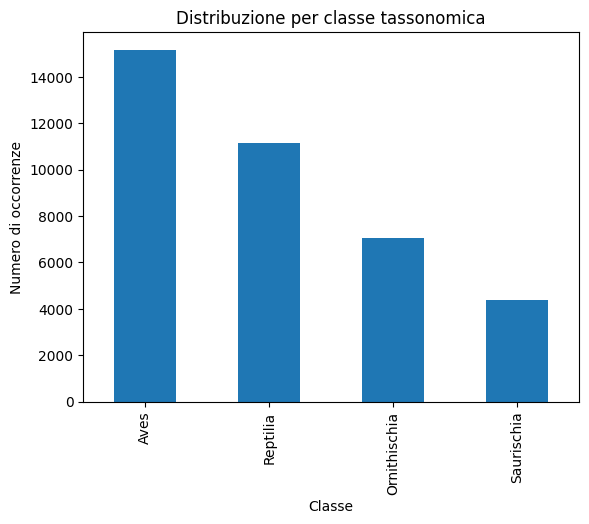

In [23]:
import matplotlib.pyplot as plt

df['class'].value_counts().plot(kind='bar')
plt.title('Distribuzione per classe tassonomica')
plt.xlabel('Classe')
plt.ylabel('Numero di occorrenze')
plt.show()

Il grafico conferma la prevalenza di Aves seguita da Reptilia; le classi Ornithischia e Saurischia sono nettamente meno rappresentate nel dataset grezzo.


NB: Aves rappresenta ~40% del dataset (15.173/37.790). Verrà escluso in fase ETL secondo le specifiche del progetto (README).

## Conclusioni EDA — dinos.csv

**Attributi disponibili:** il dataset contiene 38 colonne, che coprono identificazione tassonomica (`identified_name`, `accepted_name`, `phylum`, `class`, `order`, `family`, `genus`), localizzazione geografica (`lng`, `lat`, `cc`, `state`, `county`), informazioni temporali (`early_interval`, `late_interval`, `max_ma`, `min_ma`) e stratigrafiche (`formation`, `geological_group`, `member`).

**Tipologie di dati:** principalmente stringhe (nomi, classificazioni, paesi) e numerici float/int (coordinate, età in milioni di anni, identificativi).

**Valori mancanti:** presenti e concentrati in modo non casuale ma strutturale. Le colonne più colpite sono `geological_group` (~72%), `order` (**58.76%**, valore corretto dopo normalizzazione dei placeholder testuali `NO_ORDER_SPECIFIED`), `formation`/`genus` (~38% ciascuna), `family` (**31.14%**, corretto da `NO_FAMILY_SPECIFIED`) e `state` (~17%). Il controllo `value_counts(dropna=False)` ha rivelato che `order` e `family` contenevano placeholder testuali non intercettati da `isnull()`, da qui la necessità di normalizzarli prima del calcolo finale delle percentuali.

**Duplicati:** nessuna riga duplicata rilevata (0 su 37.790 record).

**Campi utili per analisi:** `class` (con Aves dominante al ~40%, da escludere in fase ETL secondo le specifiche del progetto), `early_interval` (da raggruppare in `period_group`: Triassico/Giurassico/Cretaceo), `cc` (concentrato su pochi paesi: USA, Canada, Spagna, Cina) e `formation` (Morrison, Hell Creek, Dinosaur Park come hotspot principali) sono i campi più promettenti per costruire le visualizzazioni della dashboard Power BI e rispondere alle domande analitiche del progetto.